#Importing all python libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#Load the datasets

In [ ]:
df = pd.read_excel("/content/netflix_titles.xlsx")

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8809 entries, 0 to 8808
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8809 non-null   object
 1   type          8809 non-null   object
 2   title         8809 non-null   object
 3   director      6175 non-null   object
 4   cast          7984 non-null   object
 5   country       7978 non-null   object
 6   date_added    8799 non-null   object
 7   release_year  8809 non-null   int64 
 8   rating        8805 non-null   object
 9   duration      8806 non-null   object
 10  listed_in     8809 non-null   object
 11  description   8809 non-null   object
dtypes: int64(1), object(11)
memory usage: 826.0+ KB


In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df['date_added'] = df['date_added'].str.strip()
df["date_added"] = pd.to_datetime(df["date_added"], format = "%B %d, %Y")

In [ ]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

In [ ]:
df['release_decade'] = (df['release_year']//10)*10

In [ ]:
df['is_Movie'] = df['type'].apply(lambda x : 1 if x == 'Movie' else 0)

In [ ]:
df['Content_Type'] = df['type']

In [ ]:
Top_countries = df['country'].value_counts().head(5)
Top_countries

,count
country,
United States,2819
India,972
United Kingdom,419
Japan,245
South Korea,200


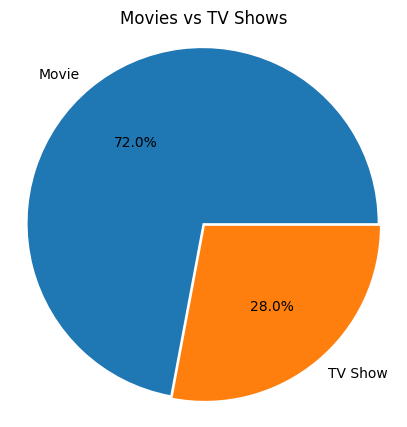

In [37]:

content_counts = df['Content_Type'].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(content_counts, labels=content_counts.index, autopct='%1.1f%%', explode = [0.01, 0.01])
plt.title('Movies vs TV Shows')
plt.axis('equal')
plt.savefig('pie.png')
plt.show()

1. Movies dominate the dataset (72%)<br>
2. TV Shows make up 28%<br>
3. Large gap between categories<br>
    There is a 44% difference between movies and TV shows.<br>
    This suggests movies are more than 2.5 times the number of TV shows.


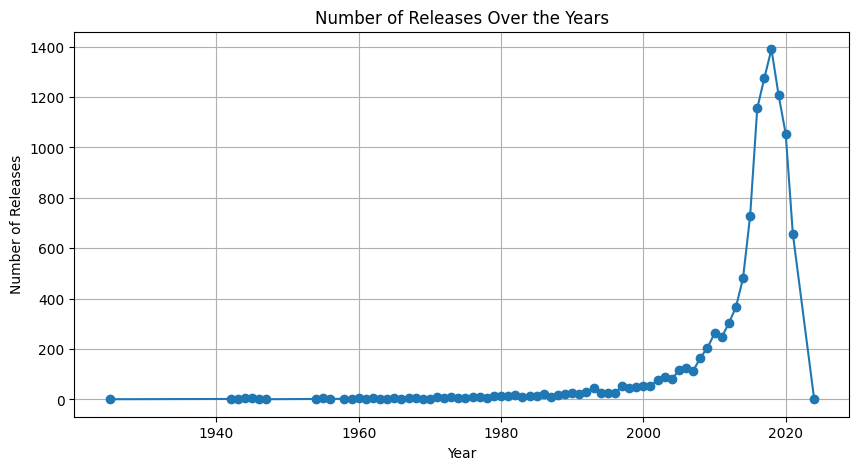

In [ ]:
year_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10, 5))
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Number of Releases')
plt.title('Number of Releases Over the Years')
plt.savefig('year.png')
plt.grid(True)
plt.show()

##Insights


1️⃣ Early Years (1920s–1980s): Very Low Activity<br>
2️⃣ Gradual Growth Phase (1990–2005)<br>
3️⃣ Rapid Expansion Phase (2006–2019) 🚀<br>
4️⃣ Decline Phase (2020–2022) 📉<br>
5️⃣ 2023 Drop to Near Zero<br>



In [ ]:
genre_series = df['listed_in'].str.strip(',').explode()

Top_genre = genre_series.value_counts().head(10)
Top_genre

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,220
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


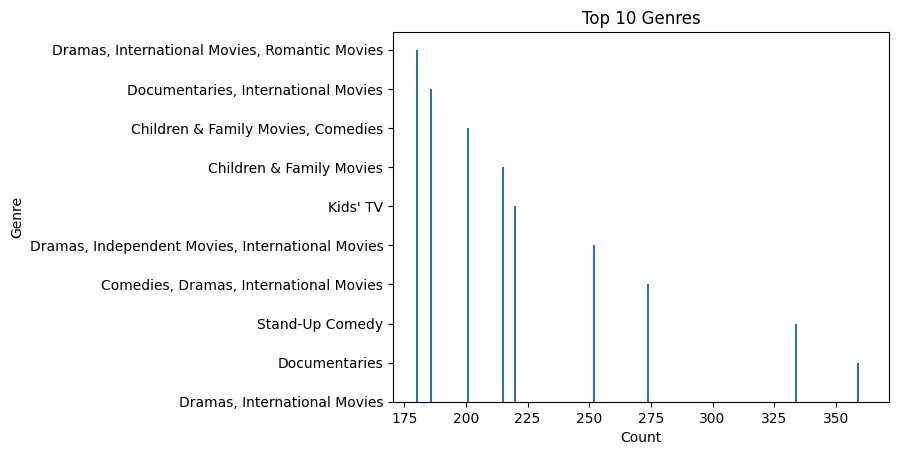

In [ ]:
plt.figure()
plt.bar(Top_genre.values, Top_genre.index)
plt.xlabel("Count")
plt.ylabel("Genre")
plt.title("Top 10 Genres")
plt.savefig('genre.png')
plt.show()

##Insights :
"The bar plot shows that International content, Drama, and Comedy are the most popular genres. Family-oriented content and documentaries also have significant presence, indicating a diverse content offering that caters to different audience preferences."

In [ ]:
df['country'].dtype

dtype('O')

In [ ]:
Top_countries

,count
country,
United States,2819
India,972
United Kingdom,419
Japan,245
South Korea,200


In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'release_decade', 'is_Movie', 'Content_Type'],
      dtype='object')

In [ ]:
df['country'] = df['country'].fillna('Unknown')
df['country'] = df['country'].str.split(', ')
df = df.explode('country')

In [ ]:
top_countries = df['country'].value_counts().head(10).index
top_countries

Index(['United States', 'India', 'Unknown', 'United Kingdom', 'Canada',
       'France', 'Japan', 'Spain', 'South Korea', 'Germany'],
      dtype='object', name='country')

In [ ]:
df_top = df[df['country'].isin(top_countries)]
df_top

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,release_decade,is_Movie,Content_Type
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2020,1,Movie
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2020,0,TV Show
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2020,0,TV Show
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2020,0,TV Show
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2020,0,TV Show
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2000,1,Movie
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2000,1,Movie
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2010,1,Movie
8807,s8808,TV Show,Parasyte: The Grey,Yeon Sang-ho,"Shin Hyun-been, Jeon Yeo-bin, Goo Kyo-hwan",South Korea,2024-04-05,2024,TV-MA,1 Season,"Sci-fi, Horror, Action",A new breed of parasitic aliens arrive on Eart...,2020,0,TV Show


In [ ]:
heatmap_data = df_top.pivot_table(
    index='country',
    columns='type',
    aggfunc='size',
    fill_value=0
)


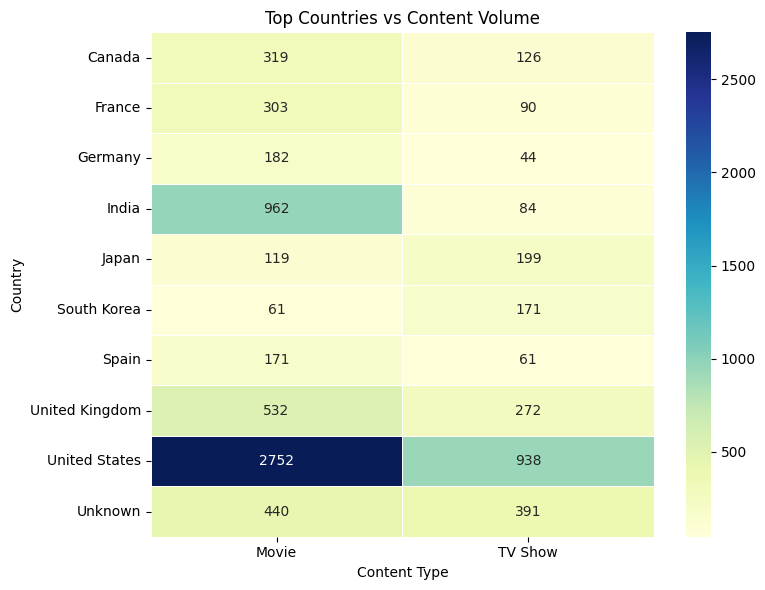

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    linewidths=0.5,
    cmap='YlGnBu'
)

plt.title('Top Countries vs Content Volume')
plt.xlabel('Content Type')
plt.ylabel('Country')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.savefig('heatmap.png')
plt.tight_layout()
plt.show()

##Insights :
"The heatmap shows that the United States dominates content production, especially in movies. Most countries produce more movies than TV shows, while Asian countries like Japan and South Korea have a higher preference for TV shows. Overall, movies remain the dominant content type globally."

##Conclusion
The analysis shows that the platform offers a wide range of content, with movies being the dominant type. Content production has grown rapidly in recent years, reflecting increasing demand. Popular genres such as Drama and Comedy indicate audience preferences, while country-wise analysis highlights the dominance of the United States along with contributions from other countries. Overall, the platform provides diverse and globally distributed content.

##Future Improvements

1. Handle missing data more effectively

2. Perform deeper genre analysis

3. Use advanced visualizations

4. Apply machine learning for recommendations